<a href="https://www.kaggle.com/code/stutisharma22/predicting-road-accident-risk?scriptVersionId=265979907" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

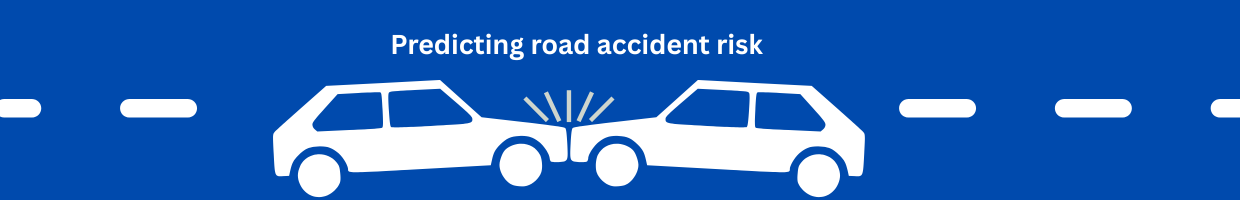

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_10k.csv
/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_2k.csv
/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_100k.csv
/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


# **Importing required libraries**

In [2]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from math import sqrt

# **Loading the data**

In [3]:
#reading data from the files
df_train= pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
df_test= pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")
df_original= pd.read_csv("/kaggle/input/simulated-roads-accident-data/synthetic_road_accidents_100k.csv")

In [4]:
#resetting the index
df_train= df_train.set_index('id')
df_test= df_test.set_index('id')

In [5]:
#viewing first five rows of the dataset
df_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [6]:
df_original.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,rural,2,0.29,70,night,rainy,False,True,evening,False,False,1,0.64
1,highway,1,0.34,25,dim,clear,False,False,morning,False,False,3,0.27
2,rural,2,0.76,70,night,foggy,True,False,evening,True,True,1,0.76
3,rural,3,0.37,70,night,foggy,True,False,morning,False,True,0,0.60
4,highway,3,0.39,45,dim,rainy,False,True,morning,False,False,0,0.17


In [7]:
combined_df = pd.concat([df_train, df_original])
combined_df.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [8]:
#number of columns and data types in the train dataset
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617754 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               617754 non-null  object 
 1   num_lanes               617754 non-null  int64  
 2   curvature               617754 non-null  float64
 3   speed_limit             617754 non-null  int64  
 4   lighting                617754 non-null  object 
 5   weather                 617754 non-null  object 
 6   road_signs_present      617754 non-null  bool   
 7   public_road             617754 non-null  bool   
 8   time_of_day             617754 non-null  object 
 9   holiday                 617754 non-null  bool   
 10  school_season           617754 non-null  bool   
 11  num_reported_accidents  617754 non-null  int64  
 12  accident_risk           617754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 49.5+ MB


In [9]:
combined_df.shape, df_test.shape

((617754, 13), (172585, 12))

In [10]:
#summary statistics of numerical columns in train dataset
combined_df.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,617754.000000,617754.000000,617754.000000,617754.000000,617754.000000
mean,2.492125,0.490645,46.265059,1.238979,0.357272
std,1.120034,0.275273,15.879793,0.964697,0.168832
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.240000
50%,2.000000,0.510000,45.000000,1.000000,0.350000
75%,3.000000,0.720000,60.000000,2.000000,0.470000
max,4.000000,1.000000,70.000000,10.000000,1.000000


In [11]:
#number of unique values in the columns
combined_df.nunique()

road_type                   3
num_lanes                   4
curvature                 261
speed_limit                 5
lighting                    3
weather                     3
road_signs_present          2
public_road                 2
time_of_day                 3
holiday                     2
school_season               2
num_reported_accidents     11
accident_risk             101
dtype: int64

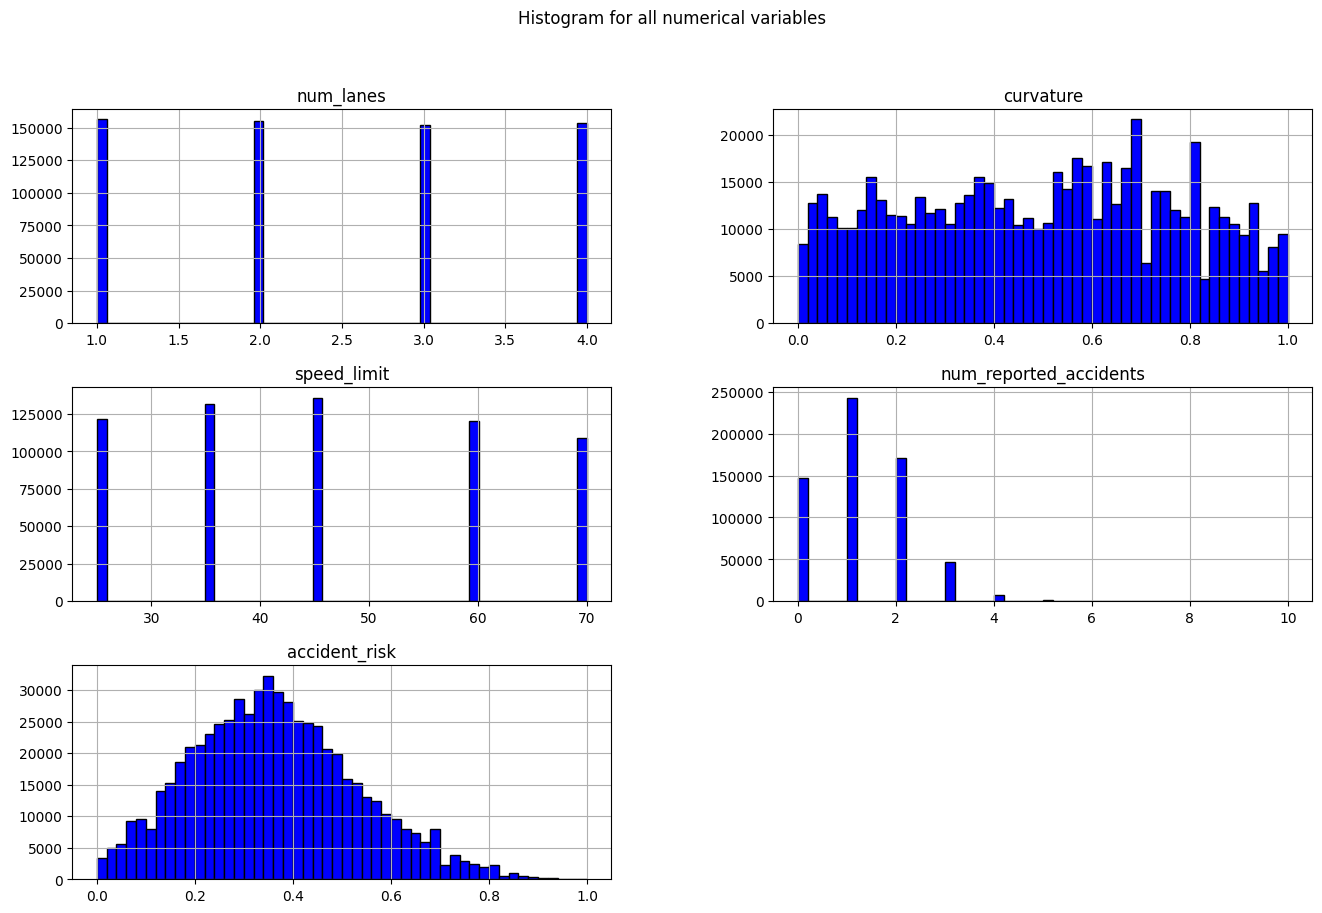

In [12]:
#plotting histogram for all the input variables
combined_df.hist(figsize=(16,10), bins=50, color='blue', edgecolor='black')
plt.suptitle("Histogram for all numerical variables")
plt.show()

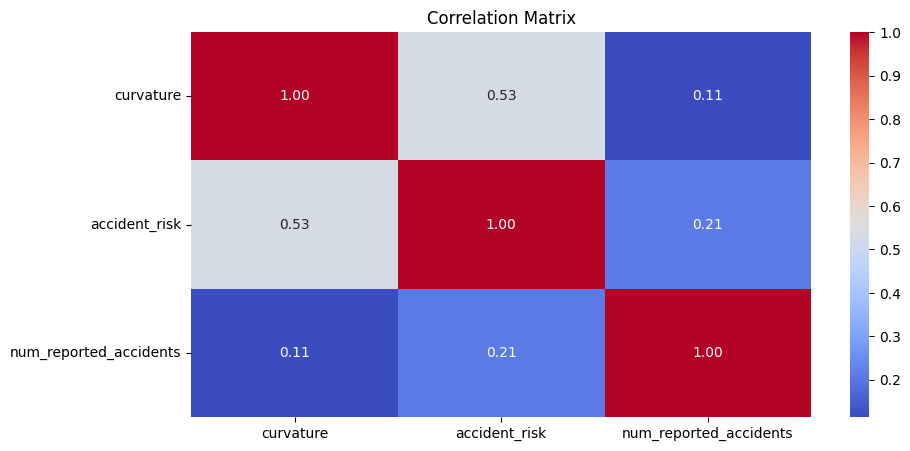

In [13]:
numerical_variables= combined_df[['curvature', 'accident_risk','num_reported_accidents']]
correlation_matrix= numerical_variables.corr()
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

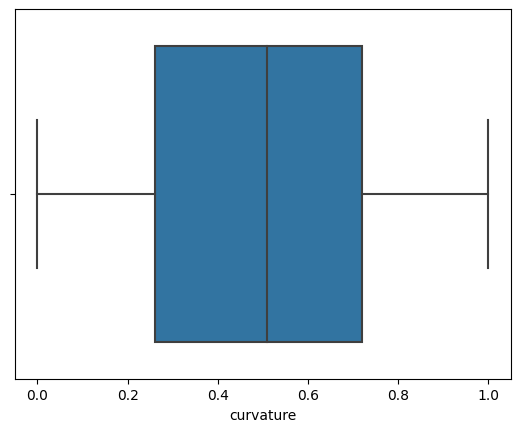

In [14]:
sns.boxplot(data= combined_df,x='curvature' )
plt.show()

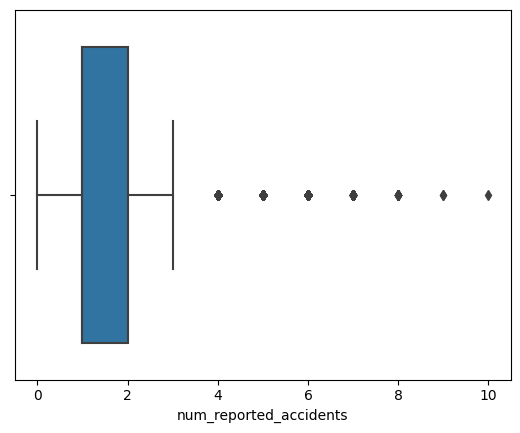

In [15]:
sns.boxplot(data= combined_df,x='num_reported_accidents' )
plt.show()

# **Feature processing**

In [16]:
#categorical variables in the dataset
categorical_variables= ['num_lanes', 'speed_limit', 'road_type', 'lighting','weather','road_signs_present','public_road',
                        'time_of_day','holiday','school_season']
categorical_variables

['num_lanes',
 'speed_limit',
 'road_type',
 'lighting',
 'weather',
 'road_signs_present',
 'public_road',
 'time_of_day',
 'holiday',
 'school_season']

In [17]:
#Encoding categorical variables using one-hot encoding
combined_df= pd.get_dummies(combined_df, columns=categorical_variables, drop_first=True)
df_test= pd.get_dummies(df_test, columns=categorical_variables, drop_first=True)

In [18]:
#replacing True and False with 1 and 0
combined_df=combined_df.replace({True: 1, False: 0})
df_test=df_test.replace({True: 1, False: 0})

/tmp/ipykernel_13/2338745942.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df=combined_df.replace({True: 1, False: 0})
/tmp/ipykernel_13/2338745942.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test=df_test.replace({True: 1, False: 0})


# **Standardizing the data**

In [19]:
#Standardizing the features
scaler= RobustScaler()
X_train= combined_df.drop('accident_risk', axis=1)
y_train= combined_df['accident_risk']
X_test= df_test.copy()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
X_train_scaled= pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled= pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# **Splitting the data**

In [20]:
#splitting the data into train and test set
X_train,X_test,y_train,y_test= train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)   

# **Models used**

In [21]:
#models with parameters
model1= LinearRegression()
model2= lgb.LGBMRegressor(objective='regression', random_state=42, learning_rate=0.1, n_estimators=100)
model3= xgb.XGBRegressor(objective='reg:squarederror', 
                             n_estimators=100,            
                             learning_rate=0.1,          
                             max_depth=4,                 
                             subsample=0.8,               
                             colsample_bytree=0.8,     
                             random_state=42)
model4= GradientBoostingRegressor(random_state=7)
final_model = VotingRegressor(estimators=[('lr', model1), ('lgb', model2),('xgb', model3),('gb', model4)], 
                              weights=[1,2,1,1])

# **Model fitting**

In [22]:
#fitting the model to training data
final_model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 494203, number of used features: 21
[LightGBM] [Info] Start training from score 0.357184


VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('lgb',
                             LGBMRegressor(objective='regression',
                                           random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamm...
                                          interaction_constraints=None,
                                          learning_rate=0.1, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=4,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=42, ...)),
                            ('gb', GradientBoostingRegressor(random_state=7))],
                weights=[1, 2, 1, 1])

# **Predictions**

In [23]:
#predicting the values for target variable
y_pred= final_model.predict(X_test)

In [24]:
#calculating root mean squared error
rmse= sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 0.0568757287618024


In [25]:
#predicting values for test data
output= pd.DataFrame({'id':df_test.index, 'accident_risk': final_model.predict(X_test_scaled)})
output.to_csv('submission.csv', index= False)